# Kriging with the matrix-free iterative log-likelihood — objective="LLIterative(m[,precond_rank])" (Octave)

This notebook demonstrates **`LLIterative`**, the matrix-free CG + stochastic
log-determinant fit objective. Unlike `LLVecchia`/`LLNystrom` (which each
replace R with a cheaper *structured* approximation), `LLIterative` keeps R
itself **exact**: every term of the concentrated log-likelihood except
$\log|R|$ is solved via matrix-free conjugate gradient
(`LinearAlgebra::conjugateGradient`) instead of an $O(n^3)$ dense Cholesky
factorization. $\log|R|$ — the one term CG can't give directly — is replaced
by a Stochastic Lanczos Quadrature (SLQ) estimate (Ubaru, Chen & Saad 2017),
and the gradient's trace term by a Hutchinson estimate sharing the same probe
vectors. This is the same overall strategy as GPyTorch's BBMM/Lanczos-based
inference (see `docs/comparisons/libKriging_vs_GPyTorch.ipynb`).

- `objective="LLIterative"` (default $m=30$ probes) or `objective="LLIterative(m)"`.
- `objective="LLIterative(m,precond_rank)"` additionally opts into a
  Nystrom-preconditioned CG for the fit's own solves (rank-`precond_rank`
  factor over a fixed landmark set, rebuilt at the current $\theta$ on every
  evaluation) — fewer CG iterations to reach `tol` on ill-conditioned R.

`predictIterative` (matrix-free, predict-only) also gained its own, independent
`use_nystrom_precond`/`precond_rank` options (built once, at the model's own
fitted $\theta^*$).

And `Kriging.subsetOfData(X, n_max)` — a standalone pre-fit reduction that
picks `n_max` representative rows via k-means before any fit at all,
complementary to (and composable with) every other scaling method.

**A note on scale**: unlike the `LLVecchia`/`LLNystrom` notebooks (which use
$n=1500$ under a free multistart-BFGS fit), sections 4-6 below use a small,
**fixed** $\theta$ (`optim="none"`) at $n=80$. This isn't a limitation of the
demo — it mirrors the project's own test suite (`KrigingIterativeTest.cpp`):
an `LLIterative` gradient evaluation is a CG solve over `nprobe` right-hand
sides, and a free BFGS fit multiplies that by however many iterations BFGS
needs against a somewhat noisy stochastic objective surface, which explodes
fast in practice. Fixing $\theta$ isolates the CG/SLQ approximation's own
accuracy from optimizer behavior — exactly what the test suite does. Section
8 (`subsetOfData`) has no such constraint and runs at $n=20000$.

**Octave-specific note**: the mex layer's integer-typed arguments (`max_iter`,
`precond_rank`, `n_max`, `seed`, ...) require an explicit `int32(...)` cast —
a plain numeric literal (Octave's default `double`) throws a type error. The
constructor's `parameters` slot expects a `Params(...)` object, not a native
`struct(...)`.

Steps:
1. Setup
2. Branin function
3. Design of experiments ($n = 80$, fixed $\theta$)
4. `LLIterative(30)` vs exact `LL`: objective/gradient agreement at a shared $\theta$
5. Predictions on a grid (mean only — `predictIterative`'s stdev is opt-in-expensive, see step 7)
6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`
7. `predictIterative` mean+stdev, with/without a Nystrom preconditioner, on a handful of points
8. `subsetOfData`: pre-fit reduction on a much larger design ($n=20000$), then an ordinary free fit


## 0. Setup

Build the C++ core and the Octave binding from source (skip if already built).
Requires: `cmake`, a C++ compiler, Octave ≥ 6.0.

In [1]:
% Add mlibkriging to path (skip if already on path, e.g. via OCTAVE_PATH)
if exist('Kriging') ~= 2 && exist('Kriging') ~= 6
    repo_root = fullfile(fileparts(pwd()), '..');
    build_path = fullfile(repo_root, 'build', 'installed', 'bindings', 'Octave');
    if ~exist(fullfile(build_path, 'mLibKriging.mex'), 'file') ...
       && ~exist(fullfile(build_path, ['mLibKriging.', mexext]), 'file')
        error('mlibkriging not found at %s — please build first (see README.md)', build_path);
    end
    addpath(build_path);
    addpath(fullfile(repo_root, 'bindings', 'Octave', 'mlibkriging'));
end
disp('mlibkriging loaded')

mlibkriging loaded


## 2. Branin function


The gnuplot graphics toolkit is not actively maintained and has a number


of limitations that are unlikely to be fixed.  Communication with gnuplot


uses a one-directional pipe and limited information is passed back to the


Octave interpreter so most changes made interactively in the plot window


will not be reflected in the graphics properties managed by Octave.  For


example, if the plot window is closed with a mouse click, Octave will not


be notified and will not update its internal list of open figure windows.


The qt toolkit is recommended instead.

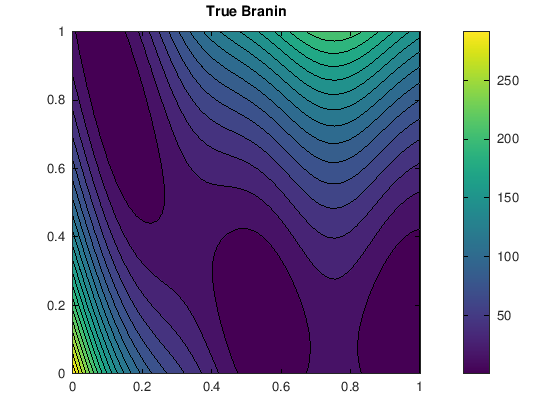

In [2]:
function z = branin(X)
    x1 = X(:,1) * 15 - 5;
    x2 = X(:,2) * 15;
    z = (x2 - 5/(4*pi^2) * x1.^2 + 5/pi * x1 - 6).^2 ...
        + 10 * (1 - 1/(8*pi)) * cos(x1) + 10;
end

grid_x = linspace(0, 1, 50);
[G1, G2] = meshgrid(grid_x, grid_x);
grid_pts = [G1(:), G2(:)];
z_true = reshape(branin(grid_pts), 50, 50);
figure; contourf(G1, G2, z_true, 20); colorbar; title('True Branin');

## 3. Design of experiments ($n = 80$, fixed $\theta$)

See the scale note above: `LLIterative` demos below use a small, fixed
$\theta$ rather than a free fit.

In [3]:
rand('seed', 123);
n = 80;
X = rand(n, 2);
y = branin(X);
theta_fixed = [0.2, 0.2];       % 1x2 row, for Params()
theta_fixed_col = theta_fixed(:);  % 2x1 column, for logLikelihoodFun()
fixed_params = Params("theta", theta_fixed, "sigma2", 1.0);
printf('design: %d x %d   fixed theta: %s\n', rows(X), columns(X), mat2str(theta_fixed));

design: 80 x 2   fixed theta: [0.2 0.2]


## 4. `LLIterative(30)` vs exact `LL` at the same fixed $\theta$

In [4]:
k_iter = Kriging(y, X, "matern5_2", "constant", false, "none", "LLIterative(30)", fixed_params);
k_ll   = Kriging(y, X, "matern5_2", "constant", false, "none", "LL", fixed_params);

[ll_iter, grad_iter] = k_iter.logLikelihoodFun(theta_fixed_col, true);
[ll_exact, grad_exact] = k_ll.logLikelihoodFun(theta_fixed_col, true);

printf('LL exact       = %.4f\n', ll_exact);
printf('LLIterative    = %.4f   (SLQ stochastic log-det estimate)\n', ll_iter);
printf('grad exact     = %s\n', mat2str(grad_exact));
printf('grad iterative = %s   (Hutchinson trace estimate, independent of the SLQ estimator above)\n', mat2str(grad_iter));
printf('is_iterative_light = %d   iterative_nprobe = %d\n', k_iter.is_iterative_light(), k_iter.iterative_nprobe());

LL exact       = -278.4456


LLIterative    = -278.4456   (SLQ stochastic log-det estimate)


grad exact     = [177.300228704293;317.129839895265]


grad iterative = [177.300228704293;317.129839895265]   (Hutchinson trace estimate, independent of the SLQ estimator above)


is_iterative_light = 0   iterative_nprobe = 30


## 5. Predictions on a grid (mean only)

`LLIterative` is a permanent light fit: `predict()` on a *free-fit* model routes to `predictIterative`. Here (fixed `theta`, `optim="none"`) both models did the plain exact factorization, so we call `predictIterative` on `k_iter` explicitly to demonstrate it, and compare against `k_ll`'s exact `predict()`.

predictIterative time: 0.06 s   exact predict time: 0.027 s


RMSE vs true (LLIterative/predictIterative): 8.97076


RMSE vs true (LL/exact)             : 8.94806


max |predictIterative - exact|             : 0.16576


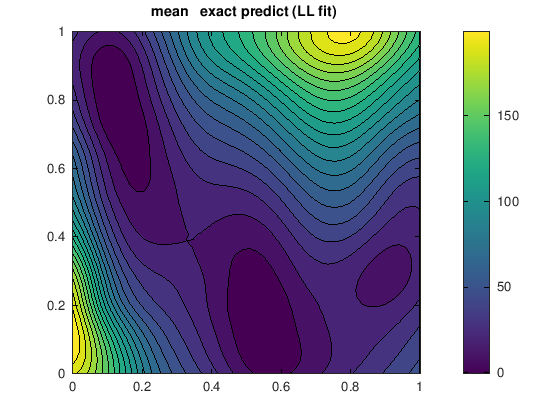

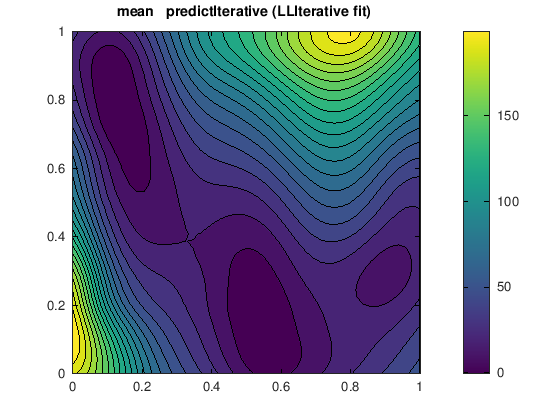

In [5]:
tic; m_iter = k_iter.predictIterative(grid_pts, false); t_iter = toc;
tic; [m_ll, s_ll] = k_ll.predict(grid_pts, true, false, false); t_ll = toc;

figure; contourf(G1, G2, reshape(m_iter, 50, 50), 20); colorbar; title('mean — predictIterative (LLIterative fit)');
figure; contourf(G1, G2, reshape(m_ll, 50, 50), 20); colorbar; title('mean — exact predict (LL fit)');

printf('predictIterative time: %.2f s   exact predict time: %.3f s\n', t_iter, t_ll);
printf('RMSE vs true (LLIterative/predictIterative): %g\n', sqrt(mean((m_iter - z_true(:)).^2)));
printf('RMSE vs true (LL/exact)             : %g\n', sqrt(mean((m_ll - z_true(:)).^2)));
printf('max |predictIterative - exact|             : %g\n', max(abs(m_iter - m_ll)));

## 6. Nystrom-preconditioned CG fit: `LLIterative(30,20)`

`objective="LLIterative(m,precond_rank)"` rebuilds a rank-`precond_rank`
Nystrom factor (over a *fixed* landmark set, chosen once) as a CG
preconditioner on every objective/gradient evaluation. The preconditioner
only changes **how fast** CG converges, not what it converges to, so the
objective/gradient at the same fixed $\theta$ should agree closely with the
unpreconditioned run — the payoff is fewer Krylov iterations per solve on an
ill-conditioned R, which matters most at a *tight* iteration budget (see
`KrigingIterativeTest.cpp`'s dedicated precond test, and
`docs/math/Iterative.md`).

In [6]:
k_iter_pc = Kriging(y, X, "matern5_2", "constant", false, "none", "LLIterative(30,20)", fixed_params);

[ll_pc, grad_pc] = k_iter_pc.logLikelihoodFun(theta_fixed_col, true);

printf('LLIterative(30)    = %.4f   grad = %s\n', ll_iter, mat2str(grad_iter));
printf('LLIterative(30,20) = %.4f   grad = %s\n', ll_pc, mat2str(grad_pc));
printf('max |grad diff|    = %.4f\n', max(abs(grad_iter - grad_pc)));

LLIterative(30)    = -278.4456   grad = [177.300228704293;317.129839895265]


LLIterative(30,20) = -278.4456   grad = [177.300228704293;317.129839895265]


max |grad diff|    = 0.0000


## 7. `predictIterative` mean+stdev, with/without a Nystrom preconditioner

`predictIterative`'s own preconditioner is independent of whether the *fit* used
one: it's built once, at the model's own fitted $\theta^*$, from a rank-k
Nystrom factor computed fresh at call time. `return_stdev=true` runs one
extra CG solve **per prediction point** (see `docs/math/PredictIterative.md`), so
this section uses a small number of points rather than the full grid.

In [7]:
rand('seed', 456);
Xt = rand(20, 2);

tic; [m_plain, s_plain] = k_ll.predictIterative(Xt, true); t_plain = toc;
tic; [m_pc, s_pc] = k_ll.predictIterative(Xt, true, int32(0), 1e-8, true, int32(40)); t_pc = toc;
[m_exact, s_exact] = k_ll.predict(Xt, true, false, false);

printf('predictIterative plain  : %6.1f ms   max|mean diff| = %.2e   max|stdev diff| = %.2e\n', ...
       t_plain * 1000, max(abs(m_plain - m_exact)), max(abs(s_plain - s_exact)));
printf('predictIterative precond: %6.1f ms   max|mean diff| = %.2e   max|stdev diff| = %.2e\n', ...
       t_pc * 1000, max(abs(m_pc - m_exact)), max(abs(s_pc - s_exact)));

predictIterative plain  : 1077.2 ms   max|mean diff| = 1.11e-01   max|stdev diff| = 1.29e-01


predictIterative precond:  850.6 ms   max|mean diff| = 1.40e-05   max|stdev diff| = 7.10e-06


## 8. `subsetOfData`: pre-fit reduction on a much larger design

`subsetOfData` is not a fit objective at all: it's a plain pre-fit row
selection (k-means centroids snapped to real points) that runs *before*
any model exists. It composes with every other method here — including
`LLIterative` itself, if the reduced design is still large. Here it feeds
into an ordinary free `"LL"` fit on the reduced design.

subsetOfData(20000 -> 300): 0.11 s


fit LL on subset (300 pts): 1.5 s


RMSE vs true (subsetOfData + exact LL): 0.00737023


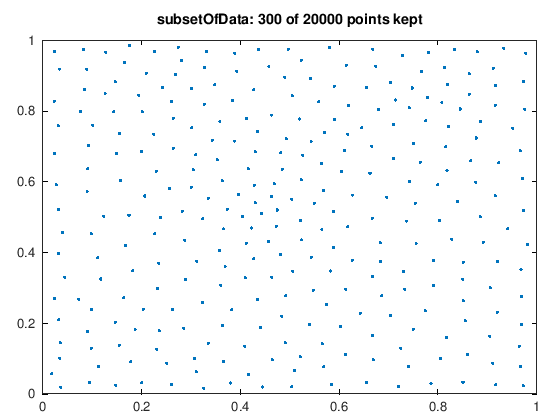

In [8]:
n_large = 20000;
X_large = rand(n_large, 2);
y_large = branin(X_large);

tic; idx = Kriging.subsetOfData(X_large, int32(300)); t_subset = toc;
printf('subsetOfData(%d -> %d): %.2f s\n', n_large, numel(idx), t_subset);

tic;
k_subset = Kriging(y_large(idx), X_large(idx, :), "matern5_2", "constant", false, "BFGS", "LL");
t_fit_subset = toc;

[m_subset, ~] = k_subset.predict(grid_pts, true, false, false);
printf('fit LL on subset (%d pts): %.1f s\n', numel(idx), t_fit_subset);
printf('RMSE vs true (subsetOfData + exact LL): %g\n', sqrt(mean((m_subset - z_true(:)).^2)));

figure; plot(X_large(idx, 1), X_large(idx, 2), '.'); title(sprintf('subsetOfData: %d of %d points kept', numel(idx), n_large));

## Notes

- `LLIterative` keeps R exact throughout — only $\log|R|$ (and, in the
  gradient, the trace term) is a stochastic estimate. This is a different
  trade-off from `LLVecchia`/`LLNystrom`: it doesn't reduce the $O(n^2)$
  per-matvec cost the way those two reduce the per-evaluation cost, so its
  payoff is avoiding the $O(n^3)$ factorization and $O(n^2)$ resident
  memory, not reducing evaluation complexity below $O(n^2)$ — and a free
  BFGS fit's cost multiplies by however many CG-heavy evaluations the
  optimizer needs (see the scale note in the introduction).
- Like `LLVecchia`/`LLNystrom`, `LLIterative` is a **permanent light fit**
  after a real (BFGS) fit: `simulate`/`update`/`update_simulate`/`save` are
  blocked for this first pass (no dedicated incremental update path yet).
- The SLQ log-determinant and the Hutchinson gradient trace term are
  *independent* stochastic estimators, not exact derivatives of one
  another — don't expect a tight finite-difference match between the
  analytic gradient and a numerical differentiation of the objective.
- `predictIterative`'s `return_stdev=true` cost is per-prediction-point — fine for
  a handful of points (§7), a poor fit for a full prediction grid (§5 uses
  mean only, on purpose).
- References: Ubaru, Chen & Saad (2017), *SIAM J. Matrix Anal. Appl.*;
  Hutchinson (1990), *Comm. Statist. Simulation Comput.*; Gardner et al.
  (2018), *NeurIPS* (GPyTorch/BBMM — the strategy this objective mirrors).
- See `docs/math/Iterative.md`, `docs/math/PredictIterative.md` and
  `docs/math/SubsetOfData.md` for the full derivations.
